`conda activate r_env_standr`

In [1]:
library(reshape2)
library(Seurat)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(dittoSeq)
library(ggpubr)
library(SCpubr)
library(rstatix)
library(tidyverse)
library(RColorBrewer)
library(reticulate)
source("scripts/custom_magma.R")
source("scripts/robust_nmf_programs.R")   

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.92 loaded





── SCpubr 2.0.0.9000 ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

ℹ Have a look at extensive tutorials in SCpubr's book.

✔ If you use SCpubr in your research, please cite it accordingly.

★ If the package is useful to you, consider leaving a Star in the GitHub repository.

! Keep track of the package updates on Twitter (@Enblacar) or in the Official NEWS website.

♥ Happy plotting!



── Package version ──

CRAN:           2.0.2
Installed: 2.0.0.9000

⚠ There is a new version available onCRAN!




In [ ]:
myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/data/myeloid_rna.rds')
myeloid

In [ ]:
myeloid$Material <- recode(myeloid$Batch_for_correction,
                          '10Xv1_nuclei_multiome' = 'nuclei',
                           '10Xv3_cell_rna'='cell',
                           '10Xv3_nuclei_rna'='nuclei',
                           '10Xv3.1_nuclei_rna'='nuclei')

myeloid_subset = subset(myeloid, Material == 'cell'), invert=TRUE)
myeloid_subset

In [ ]:
myeloid_subset <- subset(myeloid_subset, Clinical_status %in% c('Primary','Recurrence'))
myeloid_subset

In [ ]:
myeloid_subset <- subset(myeloid_subset, TAM != 'unresolved')
myeloid_subset

In [29]:
cell_counts <- myeloid_subset@meta.data %>%
  group_by(TAM, Clinical_status) %>%
  summarise(Count = n())

cell_counts <- cell_counts %>%
  group_by(Clinical_status) %>%
  mutate(Percentage = Count / sum(Count) * 100) %>%
  ungroup()
cell_counts

`summarise()` has grouped output by 'TAM'. You can override using the `.groups` argument.


TAM,Clinical_status,Count,Percentage
<chr>,<chr>,<int>,<dbl>
BDM1,Primary,2022,10.73533
BDM1,Recurrence,10591,85.02047
MG2,Primary,16813,89.26467
MG2,Recurrence,1866,14.97953


In [32]:
cell_data <- myeloid_subset@meta.data %>% 
  select(SampleID, TAM, Clinical_status)

cell_counts <- cell_data %>%
  group_by(SampleID, TAM, Clinical_status) %>%
  tally(name = 'n') %>%
  ungroup()

total_counts <- cell_counts %>%
  group_by(SampleID, Clinical_status) %>%
  summarise(total = sum(n)) %>%
  ungroup()

cell_counts <- cell_counts %>%
  left_join(total_counts, by = c("SampleID", "Clinical_status"))

cell_counts <- cell_counts %>%
  mutate(Percentage = (n / total) * 100) %>%
  ungroup()
cell_counts

`summarise()` has grouped output by 'SampleID'. You can override using the `.groups` argument.


SampleID,TAM,Clinical_status,n,total,Percentage
<chr>,<chr>,<chr>,<int>,<int>,<dbl>
BT042_PD,BDM1,Recurrence,51,55,92.727273
BT042_PD,MG2,Recurrence,4,55,7.272727
BT042_pons_1,BDM1,Recurrence,67,72,93.055556
BT042_pons_1,MG2,Recurrence,5,72,6.944444
BT042_pons_2,BDM1,Recurrence,251,302,83.112583
BT042_pons_2,MG2,Recurrence,51,302,16.887417
BT072_region_1,BDM1,Recurrence,61,79,77.215190
BT072_region_1,MG2,Recurrence,18,79,22.784810
BT072_region_2,BDM1,Recurrence,201,335,60.000000


In [44]:
t_test_results <- cell_counts %>%
  group_by(TAM) %>%
  t_test(Percentage ~ Clinical_status) %>%
  adjust_pvalue(method = "bonferroni") %>%
  add_significance() %>%
  ungroup()

p <- ggplot(cell_counts, aes(x = TAM, y = Percentage, fill = Clinical_status)) +
  geom_boxplot() +
  scale_fill_manual(values = c("Primary" = "#fcc5c0", "Recurrence" = "#ae017e")) +
  labs(title = "Percentage of Monocytic Lineage Cells per Patient",
       x = "Cell Type",
       y = "Percentage of Cells",
       fill = "Clinical Status") +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(colour = "black"),
       axis.ticks = element_line(colour = "black")
  ) +
  stat_compare_means(aes(label = ..p.signif..), method = "t.test", label.x = 1.5)

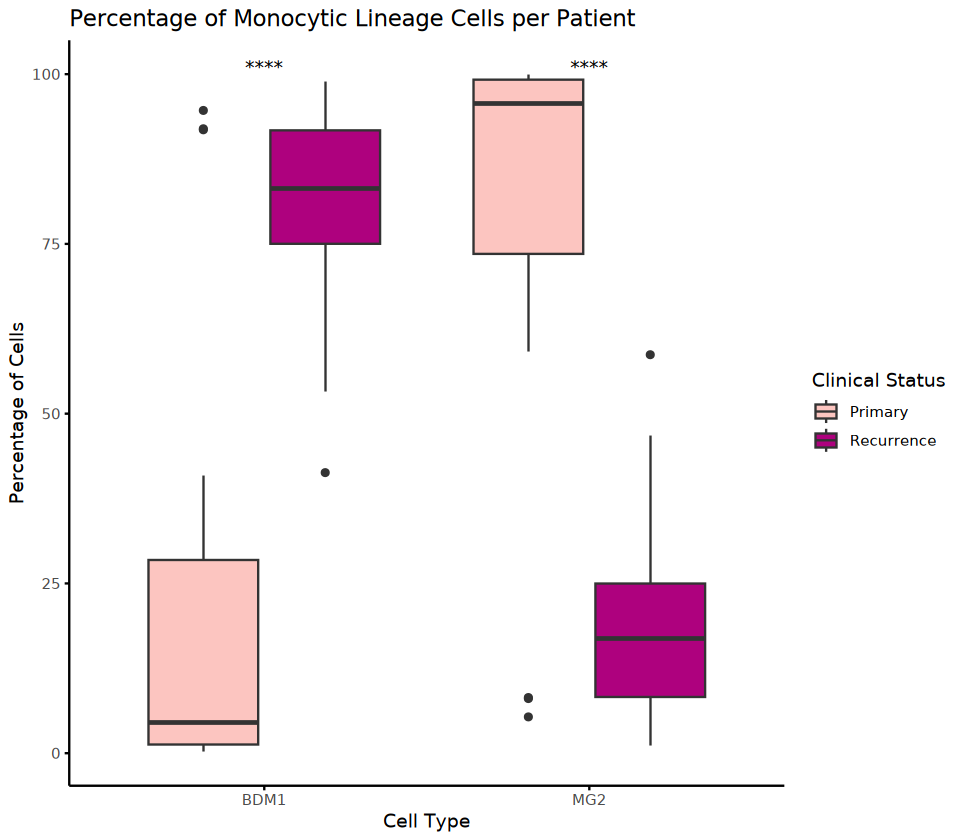

In [45]:
p

In [49]:
ggsave('figures/box_plot_TAM_per_clinical_status.pdf', width = 4, height = 3.5)

In [37]:
t_test_results

TAM,.y.,group1,group2,n1,n2,statistic,df,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
BDM1,Percentage,Primary,Recurrence,27,19,-9.151945,41.53019,1.64e-11,3.28e-11,****
MG2,Percentage,Primary,Recurrence,29,19,9.734308,44.84493,1.25e-12,2.50e-12,****
